# ECMWF Open Data — Retrieval & Plotting with earthkit

**Last updated:** 2026-05-09

---

## Learning objectives

1. Use the `ecmwf-opendata` Python client to fetch IFS, AIFS, and ENS data
2. Compare IFS and AIFS forecasts for the same field and time
3. Plot global and regional (Africa) wind vectors and precipitation with **earthkit.plots**
4. Build an ENS time-series plot showing member spread vs deterministic
5. Produce a vertical sounding profile (Skew-T, CAPE/CIN, wind barbs)

---

## Introduction

This notebook goes beyond single-file downloads.  
We fetch a **compact but representative set** of ECMWF Open Data products and use  
**earthkit** for all reading, processing, and plotting.

**Products fetched:**
- IFS ENS control — surface fields (2t, msl, 10u/v, tp) + pressure levels
- AIFS ENS control — same fields for comparison
- IFS ENS members — 2t time series for spread analysis

**Prerequisites:** Notebook A01 recommended first (catalog overview, 50r1 naming)  
**Run time:** ~15 minutes (downloads ~50 MB)  
**Data:** live from `data.ecmwf.int` — no credentials needed


## 1. Setup

We reuse project helpers (`_utils.py`) and keep everything in a single `./data` cache.


In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ECMWF client + Earthkit
from ecmwf.opendata import Client
import earthkit.data as ekd
import earthkit.plots as ekp

# Project helpers (repo: notebooks/_utils.py or _utils.py)
from _utils import get_data_dir, quick_plot

# Shared cache
DATA_DIR = Path(get_data_dir())
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data cache:", DATA_DIR)
print("earthkit-data:", ekd.__version__)
print("earthkit-plots:", getattr(ekp, "__version__", "unknown"))

def reuse(path: Path) -> bool:
    """Return True if non-empty file already exists (and report)."""
    if path.exists() and path.stat().st_size > 0:
        print(f"↪ Reusing: {path.name} ({path.stat().st_size/1e6:.1f} MB)")
        return True
    return False

# One ECMWF client (HTTP mirror by default)
c = Client(source="ecmwf")

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


Data cache: /Users/valtze/ecmwf-open-data-guide/data
earthkit-data: 0.19.4
earthkit-plots: 0.6.1


## 2. Pick a **safe** run (later used for all data requests)

Open Data mirrors publish with a lag, so we pick conservatively like in earlier Notebook 01:

- if **now ≥ 21 UTC** → **today 12z**  
- elif **now ≥ 9 UTC** → **today 00z**  
- else → **yesterday 12z**

We’ll reuse the same run across all requests so plots align.


In [2]:
now = datetime.now(timezone.utc)
if now.hour >= 21:
    run_date = now;             run_hour = 12
elif now.hour >= 9:
    run_date = now;             run_hour = 0
else:
    run_date = now - timedelta(days=1); run_hour = 12

fc_date = run_date.strftime("%Y%m%d")
fc_time = f"{run_hour:02}"
print(f"Using model run: {fc_date} at {fc_time}z")

Using model run: 20260511 at 00z


## 3. Preflight & downloads — pick a safe run and cache exactly what we need

This one cell does **all the setup** for the rest of the notebook:

- **Pins a safe IFS run** (00z or 12z with a small publish buffer).  
  If you already defined `fc_date`/`fc_time`, those are used. Otherwise we pick a conservative run based on UTC time.
- **Fetches only the files used later**, saving to the shared `./data` cache:
  - **HRES surface bundle** — `msl/2t/10u/10v`, **step 0** → `hres_sfc`
  - **HRES 2t time series** — steps **0..24 by 3 h** → `hres_ts`
  - **ENS 2t time series** — **PF + CF**, steps **0..24 by 3 h** → `ifs_pf_ts`, `ifs_cf_ts`
  - **HRES pressure levels** — `t/u/v/r`, **step 0** (for sounding) → `hres_pl`
  - **Waves** — deterministic (`wave`) & ensemble control (`waef`), **step 0** → `wave_det`, `wave_ens`
  - **AIFS single** — `msl/2t`, **step 0** (for comparisons) → `aifs_sfc`
- Uses a **“pin-or-latest”** strategy: try the pinned run first; if not yet published, **fall back to latest** so the lesson still runs.
- Performs a **light integrity check** (opens the first GRIB message) to guard against partial/corrupt downloads; bad files are removed and retried as needed.
- Updates `fc_date`/`fc_time` to the **actual run used** (after any fallback), so plot titles match the data.
- Prints a short **summary** with file sizes (or “missing” if a product isn’t available for that run).

**Outputs/variables set**

- Run info: `fc_date` (YYYYMMDD), `fc_time` ("00" or "12")
- Paths to cached files (or `None` if unavailable):
  `hres_sfc`, `hres_ts`, `ifs_pf_ts`, `ifs_cf_ts`, `hres_pl`, `wave_det`, `wave_ens`, `aifs_sfc`

> Re-running this cell is **idempotent**: existing valid files are reused.  
> Delete files in `./data` to force a fresh download.


In [3]:
# === ONE-CELL PREFLIGHT and DOWNLOAD: pick a safe run & get all needed data =================
from pathlib import Path
from datetime import datetime, timedelta, timezone
import earthkit.data as ekd
from ecmwf.opendata import Client

# ---------- 0) Shared cache dir ----------
try:
    from _utils import get_data_dir
    DATA_DIR = get_data_dir()
except Exception:
    DATA_DIR = Path("data"); DATA_DIR.mkdir(parents=True, exist_ok=True)

def _ok(p: Path) -> bool:
    try:
        p = Path(p)
        return p.exists() and p.stat().st_size > 0
    except Exception:
        return False

def _valid_grib(p: Path) -> bool:
    """Open first message to guard against partial/corrupt files."""
    try:
        ds = ekd.from_source("file", str(p))
        _ = ds[0]  # touch first message
        return True
    except Exception:
        try:
            p.unlink(missing_ok=True)
        except Exception:
            pass
        return False

# ---------- 1) Safe, conservative run (unless user already set fc_date/fc_time) ----------
if "fc_date" not in globals() or "fc_time" not in globals():
    now = datetime.now(timezone.utc)
    if   now.hour >= 22:  run_date, run_hour = now,                     12  # today's 12z should be fully online
    elif now.hour >= 10:  run_date, run_hour = now,                     0   # today's 00z
    else:                 run_date, run_hour = now - timedelta(days=1), 12  # yesterday 12z
    fc_date = run_date.strftime("%Y%m%d")
    fc_time = f"{run_hour:02d}"

print(f"[preflight] target run: {fc_date} {fc_time}z")

def _pin_or_latest(target: Path, **retrieve_kwargs) -> Path | None:
    """Try pinned (fc_date/fc_time), validate; else latest. Returns Path or None."""
    cli = Client(source="ecmwf")
    target = Path(target)

    if _ok(target) and _valid_grib(target):
        return target

    # 1) pinned
    try:
        cli.retrieve(**retrieve_kwargs, date=int(fc_date), time=int(fc_time), target=str(target))
        if _ok(target) and _valid_grib(target):
            return target
    except Exception:
        pass

    # 2) latest
    try:
        cli.retrieve(**retrieve_kwargs, target=str(target))  # no date/time -> latest
        if _ok(target) and _valid_grib(target):
            return target
    except Exception:
        pass

    return None

def _extract_run_from_file(path_like) -> tuple[str, str] | None:
    """Return (YYYYMMDD, HH) from file metadata if possible."""
    try:
        ds = ekd.from_source("file", str(path_like))
        d = str(ds[0].metadata("date"))
        t = f"{int(ds[0].metadata('time')):02d}"
        return d, t
    except Exception:
        return None

# ---------- 2) Retrieve what later cells need (idempotent, cached) ----------
print("[preflight] downloading/checking…")

# HRES surface bundle (msl/2t/10u/10v), step 0
hres_sfc = _pin_or_latest(
    DATA_DIR / "hres_msl_2t_10uv.grib2",
    model="ifs", stream="oper", type="fc", levtype="sfc",
    step=0, param="msl/2t/10u/10v"
)

# Pin titles to the *actual* run used (after any fallback)
if hres_sfc:
    maybe_run = _extract_run_from_file(hres_sfc)
    if maybe_run:
        fc_date, fc_time = maybe_run
        print(f"[preflight] run used: {fc_date} {fc_time}z")

# HRES time series (2t), steps 0..24 by 3h
hres_ts = _pin_or_latest(
    DATA_DIR / "hres_ts_2t.grib2",
    model="ifs", stream="oper", type="fc", levtype="sfc",
    step=list(range(0, 25, 3)), param="2t"
)

# ENS PF time series (2t), steps 0..24 by 3h  (kept short to avoid multi-GB)
ifs_pf_ts = _pin_or_latest(
    DATA_DIR / "ens_ts_2t_pf.grib2",
    model="ifs", stream="enfo", type="pf", levtype="sfc",
    step=list(range(0, 25, 3)), param="2t"
)

# ENS CF time series (2t), steps 0..24 by 3h
ifs_cf_ts = _pin_or_latest(
    DATA_DIR / "ens_ts_2t_cf.grib2",
    model="ifs", stream="enfo", type="cf", levtype="sfc",
    step=list(range(0, 25, 3)), param="2t"
)

# HRES pressure levels (t/u/v/r), step 0  — used by the sounding section
hres_pl = _pin_or_latest(
    DATA_DIR / "hres_pl_truv_step0.grib2",
    model="ifs", stream="oper", type="fc", levtype="pl",
    levelist="1000/925/850/700/500/300/250/200/150/100/50",
    step=0, param="t/u/v/r"
)

# Waves (deterministic) step 0
wave_det = _pin_or_latest(
    DATA_DIR / "wave_deterministic_swh_mwp_mwd.grib2",
    model="ifs", stream="wave", type="fc",
    step=0, param="swh/mwp/mwd"
)

# Waves (ensemble control) step 0
wave_ens = _pin_or_latest(
    DATA_DIR / "wave_ensemble_cf_swh_mwp_mwd.grib2",
    model="ifs", stream="waef", type="cf",
    step=0, param="swh/mwp/mwd"
)

# AIFS single (msl/2t) step 0 — used in AIFS−IFS differences
try:
    aifs_sfc = _pin_or_latest(
        DATA_DIR / "aifs_det_msl_2t.grib2",
        model="aifs-single", stream="oper", type="fc", levtype="sfc",
        step=0, param="msl/2t"
    )
except Exception:
    aifs_sfc = None

# ---------- 3) Summary ----------
def _size(p): 
    try:
        return f"{Path(p).stat().st_size/1e6:.1f} MB" if _ok(p) else "(missing)"
    except Exception:
        return "(missing)"

print("\n[preflight] summary")
print("  HRES sfc     :", hres_sfc, _size(hres_sfc))
print("  HRES ts (2t) :", hres_ts, _size(hres_ts))
print("  ENS PF ts    :", ifs_pf_ts, _size(ifs_pf_ts))
print("  ENS CF ts    :", ifs_cf_ts, _size(ifs_cf_ts))
print("  HRES PL      :", hres_pl, _size(hres_pl))
print("  Wave det     :", wave_det, _size(wave_det))
print("  Wave ens     :", wave_ens, _size(wave_ens))
print("  AIFS sfc     :", aifs_sfc, _size(aifs_sfc))


Some requested dates are before 2026-05-12. Data before this date uses a different stream structure (06/18 UTC runs are under stream=scda/scwv) compared to data on or after 2026-05-12 (where those runs are under stream=oper/wave). This is handled automatically, but be aware that the underlying file structure differs across this boundary.


[preflight] target run: 20260511 00z
[preflight] downloading/checking…


20260511000000-0h-oper-fc.grib2:   0%|          | 0.00/2.80M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
[preflight] run used: 20260511 00z


<multiple>:   0%|          | 0.00/5.71M [00:00<?, ?B/s]

...

20260511000000-0h-wave-fc.grib2:   0%|          | 0.00/2.33M [00:00<?, ?B/s]

20260511000000-0h-waef-ef.grib2:   0%|          | 0.00/2.33M [00:00<?, ?B/s]

Model 'aifs-single' does not match the client model 'ifs', using model 'aifs-single' from retrieve


20260511000000-0h-oper-fc.grib2:   0%|          | 0.00/1.09M [00:00<?, ?B/s]


[preflight] summary
  HRES sfc     : /Users/valtze/ecmwf-open-data-guide/data/hres_msl_2t_10uv.grib2 2.9 MB
  HRES ts (2t) : /Users/valtze/ecmwf-open-data-guide/data/hres_ts_2t.grib2 6.0 MB
  ENS PF ts    : /Users/valtze/ecmwf-open-data-guide/data/ens_ts_2t_pf.grib2 303.5 MB
  ENS CF ts    : /Users/valtze/ecmwf-open-data-guide/data/ens_ts_2t_cf.grib2 6.0 MB
  HRES PL      : /Users/valtze/ecmwf-open-data-guide/data/hres_pl_truv_step0.grib2 26.7 MB
  Wave det     : /Users/valtze/ecmwf-open-data-guide/data/wave_deterministic_swh_mwp_mwd.grib2 2.4 MB
  Wave ens     : /Users/valtze/ecmwf-open-data-guide/data/wave_ensemble_cf_swh_mwp_mwd.grib2 2.4 MB
  AIFS sfc     : /Users/valtze/ecmwf-open-data-guide/data/aifs_det_msl_2t.grib2 1.1 MB


## 4. Inventory (quick check) + tiny sanity maps

### Why this step
Before we dive into time series, winds, and diagnostics, we do a quick **health check** of everything the preflight cached. Think of it as a lightweight `grib_ls` plus a couple of tiny teaser maps to verify that files open cleanly and fields look sensible.

### What this cell does
- Prints a compact **inventory** for each cached GRIB:
  - file name & size  
  - number of GRIB messages  
  - first few `shortName` values (which variables are inside)  
  - a brief summary of detected **steps** (fast scan)
- Draws small **global maps** for a representative scalar from each product:
  - IFS HRES — `2t`  
  - IFS ENS (control) — `2t`  
  - AIFS single — `2t`  
  - AIFS-ENS (control) — `2t` *(if present)*  
  - Waves deterministic — `swh`  
  - Waves ENS control — `swh`

### What you should see
- One text inventory block per file and up to **six tiny maps**.  
- If a file isn’t available yet, you’ll see **“(missing)”** and that plot is skipped.

### Tips
- This is intentionally **quick**. Detailed winds, time series, and diagnostics come later.  
- On slower machines, reduce the internal scan limit (e.g. 300 → 120 messages) inside the inventory helper.  
- Change the mini-map domain (e.g. `"Europe"`, `"USA"`) or swap the plotted `shortName` if you prefer different variables.


Inventory (grib_ls-like):

IFS HRES (sfc):
- hres_msl_2t_10uv.grib2                   2.9 MB  | msgs: 4       | shorts: 10u, 10v, 2t, msl | steps: 0

IFS HRES 2t time series:
- hres_ts_2t.grib2                         6.0 MB  | msgs: 9       | shorts: 2t | steps: 0…24 (#9)

IFS ENS PF 2t time series:
- ens_ts_2t_pf.grib2                     303.5 MB  | msgs: 450     | shorts: 2t | steps: 0, 3, 6, 9, 12, 15

IFS ENS CF 2t time series:
- ens_ts_2t_cf.grib2                       6.0 MB  | msgs: 9       | shorts: 2t | steps: 0…24 (#9)

IFS HRES pressure levels (pl):
- hres_pl_truv_step0.grib2                26.7 MB  | msgs: 44      | shorts: r, t, u, v | steps: 0

Waves deterministic:
- wave_deterministic_swh_mwp_mwd.grib2     2.4 MB  | msgs: 3       | shorts: mwd, mwp, swh | steps: 0

Waves ensemble control:
- wave_ensemble_cf_swh_mwp_mwd.grib2       2.4 MB  | msgs: 3       | shorts: mwd, mwp, swh | steps: 0

AIFS single (sfc):
- aifs_det_msl_2t.grib2                    1.1 MB  | msgs: 2 

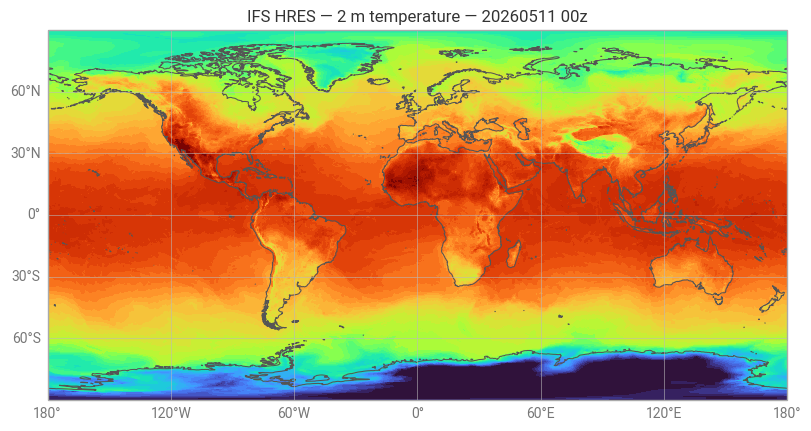

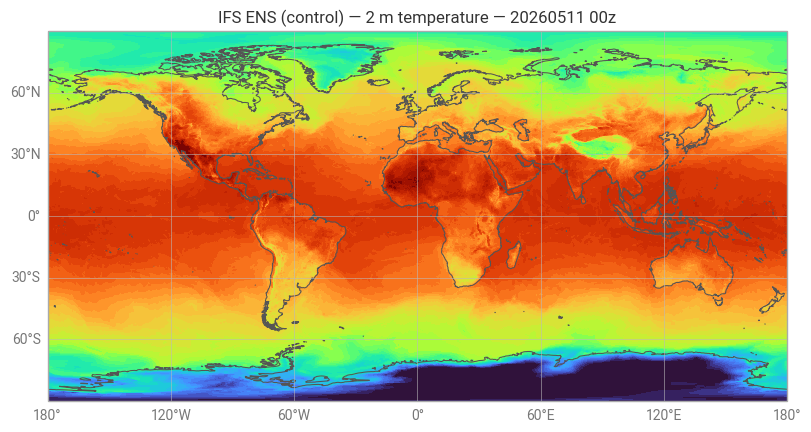

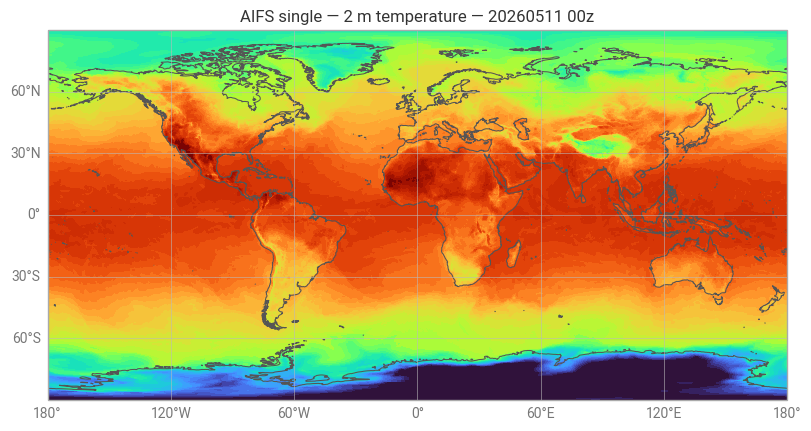

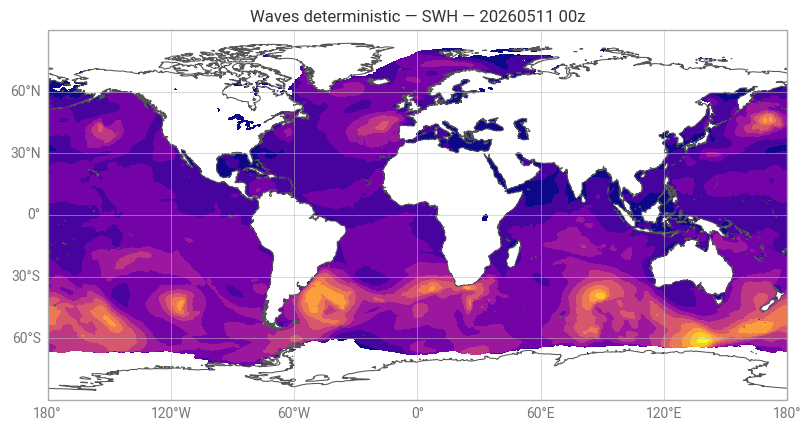

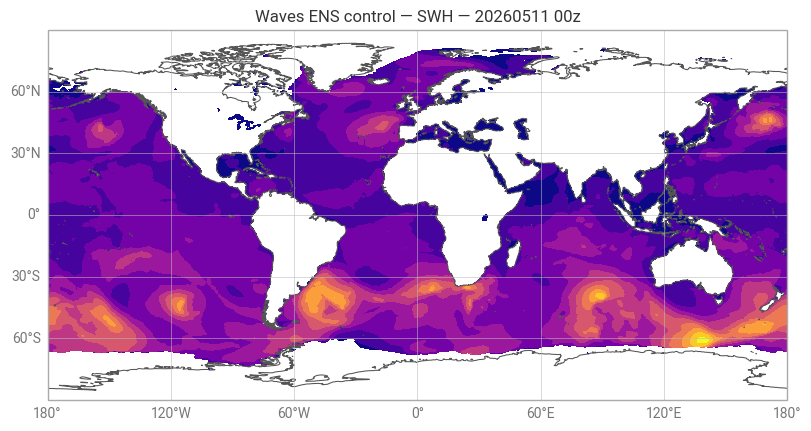

In [14]:
# --- Step 4: Inventory (fast) + tiny sanity maps --------------------------------
from pathlib import Path
import numpy as np
import earthkit.data as ekd
from IPython.display import display

# make sure optional vars exist
aifs_ens_cf = globals().get("aifs_ens_cf", None)

ITEMS = [
    ("IFS HRES (sfc)",                  hres_sfc),
    ("IFS HRES 2t time series",         hres_ts),
    ("IFS ENS PF 2t time series",       ifs_pf_ts),
    ("IFS ENS CF 2t time series",       ifs_cf_ts),
    ("IFS HRES pressure levels (pl)",   hres_pl),
    ("Waves deterministic",             wave_det),
    ("Waves ensemble control",          wave_ens),
    ("AIFS single (sfc)",               aifs_sfc),
    ("AIFS-ENS CF (sfc/time series)",   aifs_ens_cf),
]

def _ok(p):
    try:
        p = Path(p)
        return p.exists() and p.stat().st_size > 0
    except Exception:
        return False

def describe_lite(path, max_scan=300):
    """
    Fast-ish summary without reading data arrays:
    - n messages (len(ds))
    - a few shortNames (sampled)
    - a compact step summary from first max_scan messages
    """
    try:
        ds = ekd.from_source("file", str(path))
        n = len(ds)
        shorts, steps = [], []
        for i, f in enumerate(ds):
            if i >= max_scan: break
            try:
                sn = f.metadata("shortName")
                if sn: shorts.append(sn)
            except Exception:
                pass
            try:
                st = f.metadata("step")
                if st is not None: steps.append(int(st))
            except Exception:
                pass
        # compact summaries
        shorts_show = ", ".join(sorted(set(shorts))[:8])
        if len(set(shorts)) > 8:
            shorts_show += ", …"
        st_unique = sorted(set(steps))
        if len(st_unique) == 0:
            step_show = "—"
        elif len(st_unique) <= 6:
            step_show = ", ".join(map(str, st_unique))
        else:
            step_show = f"{st_unique[0]}…{st_unique[-1]} (#{len(st_unique)})"
        size_mb = path.stat().st_size / 1e6
        print(f"- {path.name:<36}  {size_mb:6.1f} MB  | msgs: {n:<7d} | shorts: {shorts_show or '—'} | steps: {step_show}")
    except Exception as e:
        print(f"- {path.name:<36}  (failed to inspect: {e!r})")

print("Inventory (grib_ls-like):")
for label, p in ITEMS:
    if _ok(p):
        print(f"\n{label}:")
        describe_lite(Path(p))
    else:
        print(f"\n{label}: (missing)")

# ------------------ Tiny sanity maps (1 scalar per model) ----------------------
def _first_field(path, short=None):
    p = Path(path)
    ds = ekd.from_source("file", str(p))
    if short is not None:
        try:
            return ds.sel(shortName=short)[0]
        except Exception:
            pass
    return ds[0]

def _title_from_file(path, base):
    try:
        ds = ekd.from_source("file", str(path))
        d = str(ds[0].metadata("date")); t = f"{int(ds[0].metadata('time')):02d}"
        return f"{base} — {d} {t}z"
    except Exception:
        return base

def quick_map(path, short, base_title):
    if not _ok(path):
        print(f"{base_title}: (missing)"); return
    try:
        fld = _first_field(path, short=short)
        import earthkit.plots as ekp
        chart = ekp.Map(domain="global")
        chart.contourf(fld, auto_style=True)
        chart.coastlines(); chart.gridlines()
        chart.title(_title_from_file(path, base_title))
        chart.show()
    except Exception as e:
        print(f"{base_title}: plot failed -> {e!r}")

print("\nSanity maps:")
# 1) IFS HRES (sfc) — 2t
quick_map(hres_sfc, "2t", "IFS HRES — 2 m temperature")

# 2) IFS ENS CF (use the CF 2t time-series file; take first step)
quick_map(ifs_cf_ts, "2t", "IFS ENS (control) — 2 m temperature")

# 3) AIFS single — 2t
quick_map(aifs_sfc, "2t", "AIFS single — 2 m temperature")

# 4) AIFS-ENS CF — 2t (if you downloaded it in your preflight)
if _ok(aifs_ens_cf):
    quick_map(aifs_ens_cf, "2t", "AIFS-ENS (control) — 2 m temperature")

# 5) Waves det — swh
quick_map(wave_det, "swh", "Waves deterministic — SWH")

# 6) Waves ENS control — swh
quick_map(wave_ens, "swh", "Waves ENS control — SWH")


## 5. 10-m wind vectors: barbs (global) & quiver (Africa, coloured)

### What we plot
10-m wind components (`10u`, `10v`) from the HRES surface bundle downloaded in the preflight.

### Two views
- **Global barbs** — quick overview at full resolution.  
- **Quiver over Africa** — subsampled arrows; **colour and length reflect wind speed**; with gridlines and a colorbar.

### How to read it
- `10u` / `10v` are eastward / northward components on the 0.25° grid.  
- **Quiver arrows** point **towards** the flow direction.  
- **Barbs** follow the meteorological convention (flags at the tail).

### What you can tweak
- **Domain**: change `"global"` to `"Europe"`, `"Africa"`, `"USA"`, etc.  
- **Density** (quiver): `Subsample(nx=…, ny=…)` — larger → fewer arrows.  
- **Arrow sizing**: `scale`, `width`, and head parameters.  
- **Colour scale**: computed from robust percentiles of speed; adjust the percentiles if you want a wider/narrower palette.  
- **Background**: add `land()`, `ocean()`, coastlines, and gridlines to taste.

### Troubleshooting
- If no arrows appear, confirm your file contains `10u` and `10v` (the HRES surface bundle does).  
- To use AIFS or ENS instead, load their datasets and select the same `shortName`s.  
- Global quiver can be heavy; keep subsampling on for performance.


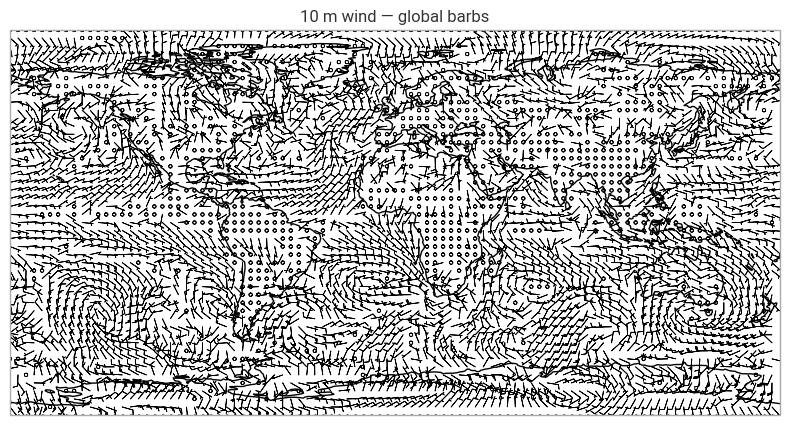

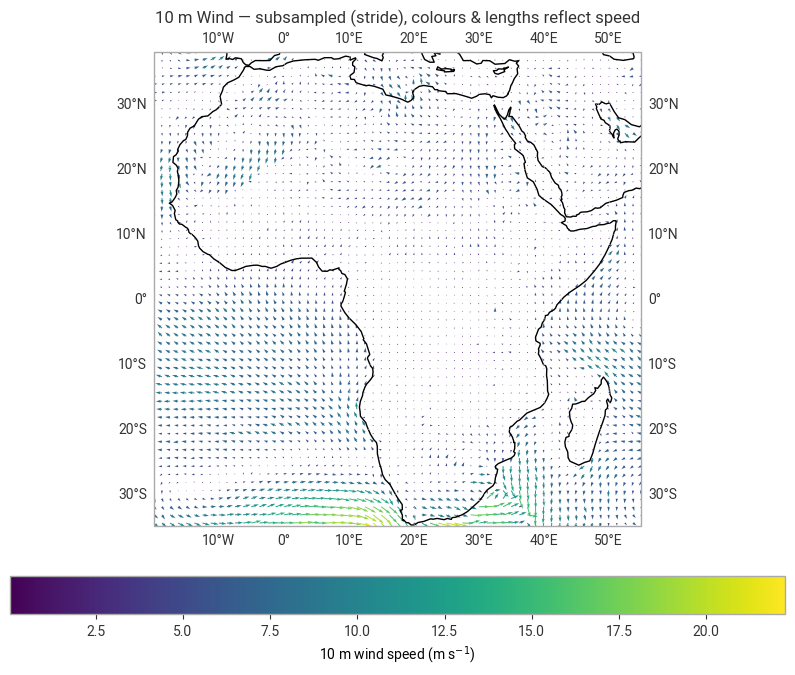

In [15]:
def barbs_global(path, stride=15):
    p = Path(path)
    if not p.exists(): return
    ds = ekd.from_source("file", str(p))
    try:
        u = ds.sel(shortName="10u")[0].to_xarray()["10u"]
        v = ds.sel(shortName="10v")[0].to_xarray()["10v"]
    except Exception:
        print("10u/10v not found"); return

    lat = u.latitude.values[::stride]
    lon = u.longitude.values[::stride]
    U = u.values[::stride, ::stride]
    V = v.values[::stride, ::stride]

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(10,5), subplot_kw=dict(projection=proj))
    ax.coastlines()
    ax.barbs(lon, lat, U, V, transform=proj, length=4, linewidth=0.6)
    ax.set_title("10 m wind — global barbs"); plt.show()

def quiver_africa_colored(path, stride=5):
    p = Path(path)
    if not p.exists(): return
    ds = ekd.from_source("file", str(p))
    try:
        u = ds.sel(shortName="10u")[0].to_xarray()["10u"]
        v = ds.sel(shortName="10v")[0].to_xarray()["10v"]
    except Exception:
        print("10u/10v not found"); return

    # Crop Africa (lon -20..55, lat -35..38)
    u = u.sel(longitude=slice(-20, 55), latitude=slice(38, -35))
    v = v.sel(longitude=slice(-20, 55), latitude=slice(38, -35))

    # Subsample
    lat = u.latitude.values[::stride]
    lon = u.longitude.values[::stride]
    U = u.values[::stride, ::stride]
    V = v.values[::stride, ::stride]
    speed = np.hypot(U, V)

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(10,8), subplot_kw=dict(projection=proj))
    ax.set_extent([-20, 55, -35, 38], crs=proj)
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, xlocs=range(-20, 60, 10), ylocs=range(-30, 40, 10), linestyle=":", linewidth=0.5)
    q = ax.quiver(lon, lat, U, V, speed, transform=proj, scale=700, width=0.002)
    cbar = plt.colorbar(q, ax=ax, orientation="horizontal", pad=0.08)
    cbar.set_label("10 m wind speed (m s$^{-1}$)")
    ax.set_title("10 m Wind — subsampled (stride), colours & lengths reflect speed")
    plt.show()

barbs_global(hres_sfc, stride=15)
quiver_africa_colored(hres_sfc, stride=5)

## 6. Time series at a point — **ENS members + Control** vs **HRES** (2 m temperature)

### Why this step
A time series at a single location is a quick way to assess **spread vs. signal**.  
We compare:
- all **ENS perturbed members (PF)** — faint lines (spread),
- the **ENS control (CF)** — bold,
- and **HRES** — as a deterministic reference.

### What this cell does
- Reads the time-series files cached in the preflight:  
  - `ens_ts_2t_pf.grib2` (PF), `ens_ts_2t_cf.grib2` (CF), `hres_ts_2t.grib2` (HRES).
- Extracts the **nearest grid point** to your chosen lon/lat.
- Ensures axes line up (uses `step` in **hours** when available).
- Converts **K → °C** for readability and plots all three together.

### How to use it
- Pick a location from the presets (or provide your own `lon, lat`).
- Re-run the cell to update the plot.

### What you should see
- Faint blue spaghetti (PF members), bold black line (CF), and a green line (HRES).
- X-axis as **forecast step (h)**, Y-axis as **°C**.

### Tweakables
- **Location**: change the preset `name` or set `lon, lat` directly.
- **Horizon**: preflight currently fetches **0..24 h by 3 h**; extend if you need more.
- **Style**: colors, alpha, and line widths are set in the plotting block.

### Troubleshooting
- If a line is missing, check the preflight summary for the corresponding file.  
- If the X-axis is “Index” instead of hours, your dataset likely lacks a proper `step` coordinate—still fine for relative comparisons.


In [18]:
# Presets: choose a location by name
PRESETS = {
    # Europe
    "Paris":        (2.35,   48.86),
    "Reading":      (-0.97,  51.44),
    "Bologna":      (11.34,  44.49),
    "Riga":         (24.10,  56.96),
    # Africa — SEWA regions
    "Addis Ababa":  (38.74,   9.03),   # Eastern Africa / ICPAC
    "Nairobi":      (36.82,  -1.29),   # Eastern Africa
    "Maputo":       (32.59, -25.97),   # Southern Africa / SADC
    "Dakar":        (-17.44, 14.69),   # Western Africa / AGRHYMET
    "Douala":       (9.70,    4.05),   # Central Africa / CAPC-AC
    "Niamey":       (2.11,   13.51),   # Western Africa / ACMAD
}
name = "Addis Ababa"
lon, lat = PRESETS[name]
print(f"Using location: {name} (lon={lon}, lat={lat})")

Using location: Addis Ababa (lon=38.74, lat=9.03)


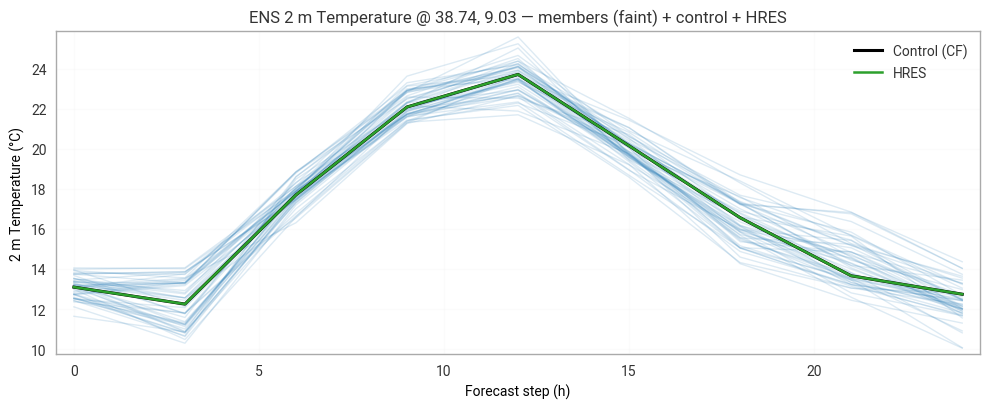

In [19]:
def two_xarray_from_ds(ds, short):
    """Return (Dataset/DataArray) for a shortName from an Earthkit dataset."""
    xa = ds.sel(shortName=short).to_xarray()
    if isinstance(xa, xr.Dataset):
        var = list(xa.data_vars)[0]
        return xa, xa[var]
    return None, xa

def ts_pf_cf_vs_hres(pf_path, cf_path, hres_path, lon, lat):
    # Load ENS PF
    pf = None
    if Path(pf_path).exists():
        ds_pf = ekd.from_source("file", str(pf_path))
        _, pf = two_xarray_from_ds(ds_pf, "2t")
        if pf is not None:
            pf = pf.sel(longitude=lon, latitude=lat, method="nearest")
            # put dims (step, number) if both exist
            dims = list(pf.dims)
            if "step" in dims and "number" in dims:
                pf = pf.transpose("step", "number")
            pf = pf - 273.15

    # Load ENS CF
    cf = None
    if Path(cf_path).exists():
        ds_cf = ekd.from_source("file", str(cf_path))
        _, cf = two_xarray_from_ds(ds_cf, "2t")
        if cf is not None:
            cf = cf.sel(longitude=lon, latitude=lat, method="nearest")
            cf = cf - 273.15

    # Load HRES
    hres = None
    if Path(hres_path).exists():
        ds_hr = ekd.from_source("file", str(hres_path))
        _, hres = two_xarray_from_ds(ds_hr, "2t")
        if hres is not None:
            hres = hres.sel(longitude=lon, latitude=lat, method="nearest")
            hres = hres - 273.15

    # Align steps if present
    def step_hours(da):
        if da is None: return None, None
        if "step" in da.coords:
            try:
                x = (da["step"] / np.timedelta64(1, "h")).values
            except Exception:
                x = da["step"].values
            return x, "Forecast step (h)"
        return np.arange(da.shape[0]), "Index"

    # Plot
    fig, ax = plt.subplots(figsize=(10,4.2))

    # PF members faint
    if pf is not None:
        x_pf, label = step_hours(pf)
        ax.plot(x_pf, pf.values, color="tab:blue", alpha=0.15, linewidth=1, label="_members" )

    # CF bold
    if cf is not None:
        x_cf, _ = step_hours(cf)
        ax.plot(x_cf, cf.values, color="k", linewidth=2.2, label="Control (CF)")

    # HRES
    if hres is not None:
        x_hr, _ = step_hours(hres)
        ax.plot(x_hr, hres.values, color="tab:green", linewidth=1.8, label="HRES" )

    ax.set_xlabel(label if pf is not None else ("Forecast step (h)" if cf is not None else "Index"))
    ax.set_ylabel("2 m Temperature (°C)")
    ax.set_title(f"ENS 2 m Temperature @ {lon:.2f}, {lat:.2f} — members (faint) + control + HRES")
    ax.grid(True, alpha=0.3); ax.legend(frameon=False, loc="best")
    plt.tight_layout(); plt.show()

ts_pf_cf_vs_hres(ifs_pf_ts, ifs_cf_ts, hres_ts, lon, lat)

## 7. Vertical profile (pressure levels) — HRES `t/u/v` (+ humidity), parcels & diagnostics

### Why this step
A vertical thermodynamic/wind profile (a “sounding-style” plot) helps you read the **environment** at a point: stability, moisture, wind shear—everything that drives weather.

### What this cell does
- Uses the preflight pressure-level file `hres_pl_truv_step0.grib2` (HRES at 0.25°) that contains:
  - **t** (temperature), **u/v** (wind), and **r** (relative humidity)  
  - *(If `r` is missing but **q** exists, the code computes RH from q, T, and p.)*
- Selects the **nearest grid point** to your lon/lat and sorts pressure **surface → top**.
- Computes and plots:
  - **T** (red) & **Td** (blue) vs **pressure (hPa)**,
  - **Parcel curves**: **SFC**, **MU (300 hPa)**, **ML (100 hPa)**, dashed,
  - **Wind barbs** along the pressure axis.
- Prints key diagnostics:
  - **CAPE/CIN** for SFC, MU, ML,
  - **LCL** pressure & height,
  - **0–6 km bulk shear**,
  - **θe** at the surface and near 850 hPa.

### How to use it
- Set your `lon, lat` (you can reuse the location from Section 6).
- Optionally change `step_index` if you fetched multiple steps in the PL file.

### What you should see
- A clean T/Td profile with 3 parcel tracks, wind barbs, and a printed diagnostics dict (J/kg, hPa, m/s/kt, K).

### Tweakables
- **Parcel depths**: MU(300 hPa) and ML(100 hPa) can be edited in the code.
- **Barb thinning**: set `barb_every` (e.g., 2 → every other level).
- **Levels**: adjust `levelist` in the preflight if you need finer vertical detail.
- **Step**: if your PL file has multiple steps, change `step_index`.

### Troubleshooting
- **File not found**: ensure `hres_pl_truv_step0.grib2` exists (check preflight summary).
- **Pressure units**: code handles both Pa and hPa automatically.
- **Coord names**: robust selectors handle variants like `isobaricInhPa`, `level`, etc.


In [20]:
# Section 8 — Sounding: T & Td + SFC/MU/ML parcels, wind barbs, CAPE/CIN, shear, LCL, θe
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import earthkit.data as ekd

from metpy.units import units
from metpy.calc import (
    dewpoint_from_relative_humidity,
    lcl,
    parcel_profile_with_lcl,
    surface_based_cape_cin,
    most_unstable_cape_cin,
    mixed_layer_cape_cin,
    most_unstable_parcel,
    mixed_parcel,
    equivalent_potential_temperature,
    pressure_to_height_std,
    relative_humidity_from_specific_humidity,
)
from metpy.interpolate import interpolate_1d

def sounding_profile(
    pl_path,
    lon,
    lat,
    title_prefix="Sounding",
    step_index=0,
    barb_every=1,          # 1=no thinning, 2=every 2nd level, etc.
    figsize=(7.6, 8.6)
):
    """
    Build a MetPy-style sounding & diagnostics from an HRES PL GRIB.
    Requires t,u,v and one of r (RH %) OR q (specific humidity).
    """

    # ---- load & helpers
    src = ekd.from_source("file", str(pl_path))

    def to_da(short):
        xa = src.sel(shortName=short).to_xarray()
        return xa[list(xa.data_vars)[0]] if isinstance(xa, xr.Dataset) else xa

    # Required wind & temp
    da_t = to_da("t")   # K
    da_u = to_da("u")   # m s-1
    da_v = to_da("v")   # m s-1

    # Humidity: prefer RH ('r'), else compute from specific humidity ('q')
    have_r = True
    try:
        da_r = to_da("r")   # %
    except Exception:
        have_r = False
        da_q = to_da("q")   # kg/kg

    # ---- robust coordinate names
    def pick(coordset, *cands):
        for c in cands:
            if c in coordset: return c
        for k in coordset:
            if getattr(coordset[k], "size", 1) > 1:
                return k
        raise KeyError(f"Could not find a suitable coordinate among {list(coordset)}")

    lon_name = pick(da_t.coords, "longitude", "lon", "x")
    lat_name = pick(da_t.coords, "latitude",  "lat", "y")

    lev_name = None
    for cand in ("isobaricInhPa", "levelist", "pressure", "isobaric", "level"):
        if cand in da_t.coords:
            lev_name = cand; break
    if lev_name is None:
        exclude = {"latitude","longitude","lat","lon","time","step","valid_time"}
        lev_name = next((c for c in da_t.coords if c not in exclude and da_t[c].size > 1), None)
    if lev_name is None:
        raise ValueError("No pressure-like coordinate found in PL file.")

    # ---- nearest gridpoint & step
    def sel_point(da):
        if "step" in da.dims and da.sizes["step"] > 1:
            da = da.isel(step=step_index)
        return da.sel({lon_name: lon, lat_name: lat}, method="nearest")

    pt_T = sel_point(da_t)  # K
    pt_U = sel_point(da_u)  # m/s
    pt_V = sel_point(da_v)  # m/s
    if have_r:
        pt_R = sel_point(da_r)  # %
    else:
        pt_Q = sel_point(da_q)  # kg/kg

    # ---- pressure (hPa), sort SFC->top
    p_vals = pt_T[lev_name].values.astype(float)
    p_hpa = p_vals / 100.0 if np.nanmean(p_vals) > 2000 else p_vals
    order = np.argsort(p_hpa)[::-1]

    p   = (p_hpa[order] * units.hectopascal)
    T   = (pt_T.values[order] * units.kelvin)
    U   = (pt_U.values[order] * units('m/s'))
    V   = (pt_V.values[order] * units('m/s'))

    if have_r:
        RHf = np.clip(pt_R.values[order] / 100.0, 1e-3, 1.0) * units.dimensionless
    else:
        q   = (pt_Q.values[order] * units('kg/kg'))
        # RH (0..1) from q, T, p
        RHf = relative_humidity_from_specific_humidity(q, T, p)

    # ---- thermodynamics
    Td     = dewpoint_from_relative_humidity(T, RHf)
    thetae = equivalent_potential_temperature(p, T, Td)

    # ---------- Parcels ----------
    p_prof_sfc, _, _, Tparcel_sfc = parcel_profile_with_lcl(p, T, Td)

    mu_p, mu_T, mu_Td = most_unstable_parcel(p, T, Td, depth=300 * units.hPa)[:3]
    ml_p, ml_T, ml_Td = mixed_parcel(p, T, Td, depth=100 * units.hPa)[:3]

    def parcel_curve(seed_T, seed_Td):
        # Seed first level with parcel start; recompute parcel profile
        T_env  = T.copy();  Td_env = Td.copy()
        T_env[0], Td_env[0] = seed_T, seed_Td
        p_prof, _, _, Tparcel = parcel_profile_with_lcl(p, T_env, Td_env)
        return p_prof, Tparcel

    p_prof_mu, Tparcel_mu = parcel_curve(mu_T, mu_Td if mu_Td is not None else ml_Td)
    p_prof_ml, Tparcel_ml = parcel_curve(ml_T, ml_Td)

    # ---------- Diagnostics ----------
    cape_sfc, cin_sfc = surface_based_cape_cin(p, T, Td)
    cape_mu,  cin_mu  = most_unstable_cape_cin(p, T, Td, depth=300 * units.hPa)
    cape_ml,  cin_ml  = mixed_layer_cape_cin(p, T, Td, depth=100 * units.hPa)
    lcl_p_sfc, _      = lcl(p[0], T[0], Td[0])

    H = pressure_to_height_std(p)
    u_6 = interpolate_1d(6000 * units.m, H, U).to('m/s')
    v_6 = interpolate_1d(6000 * units.m, H, V).to('m/s')
    u_0, v_0 = U[0].to('m/s'), V[0].to('m/s')
    shear_0_6 = np.hypot((u_6 - u_0).m, (v_6 - v_0).m) * units('m/s')

    # θe at sfc and ~850 hPa
    def nearest_idx(arr, val): return int(np.argmin(np.abs(arr - val)))
    idx_850 = nearest_idx(p.to('hPa').m, 850.0)

    # ---------- Plot ----------
    P_env = p.to('hPa').m
    T_c   = T.to('degC').m
    Td_c  = Td.to('degC').m

    P_sfc = p_prof_sfc.to('hPa').m
    Tp_s  = Tparcel_sfc.to('degC').m

    P_mu  = p_prof_mu.to('hPa').m
    Tp_mu = Tparcel_mu.to('degC').m

    P_ml  = p_prof_ml.to('hPa').m
    Tp_ml = Tparcel_ml.to('degC').m

    fig, ax = plt.subplots(figsize=figsize)

    # Environment
    ax.plot(T_c,  P_env, color="tab:red",   linewidth=2, label="T")
    ax.plot(Td_c, P_env, color="tab:blue",  linewidth=2, label="Td")

    # Parcels
    ax.plot(Tp_s,  P_sfc, color="k",         linestyle="--", linewidth=1.8, label="Parcel SFC")
    ax.plot(Tp_mu, P_mu,  color="tab:green", linestyle="--", linewidth=1.8, label="Parcel MU")
    ax.plot(Tp_ml, P_ml,  color="tab:purple",linestyle="--", linewidth=1.8, label="Parcel ML")

    # LCL (surface)
    ax.axhline(lcl_p_sfc.to('hPa').m, color="k", linestyle=":", linewidth=1, alpha=0.85)

    ax.invert_yaxis()
    ax.set_ylabel("Pressure (hPa)")
    ax.set_xlabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="best")
    ax.set_title(f"{title_prefix} @ lon={lon:.2f}, lat={lat:.2f} (HRES pl, step={step_index})")

    # Wind barbs (thinned)
    ax_barb = ax.twiny()
    ax_barb.set_xlim(0, 1); ax_barb.set_xticks([]); ax_barb.set_xlabel("")
    idx = np.arange(0, len(P_env), max(1, int(barb_every)))
    ax_barb.barbs(np.ones_like(idx), P_env[idx], U[idx].m, V[idx].m, length=6, linewidth=0.8)
    ax_barb.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # ---- Diagnostics to return
    def Jkg(x): return float(x.to('J/kg').m)
    return {
        "CAPE_SFC_Jkg": Jkg(cape_sfc),
        "CIN_SFC_Jkg":  Jkg(cin_sfc),
        "CAPE_MU_Jkg":  Jkg(cape_mu),
        "CIN_MU_Jkg":   Jkg(cin_mu),
        "CAPE_ML_Jkg":  Jkg(cape_ml),
        "CIN_ML_Jkg":   Jkg(cin_ml),
        "LCL_hPa":      float(lcl_p_sfc.to('hPa').m),
        "LCL_m":        float(pressure_to_height_std(lcl_p_sfc).to('meter').m),
        "Shear_0_6km_ms": float(shear_0_6.to('m/s').m),
        "Shear_0_6km_kt": float(shear_0_6.to('knots').m),
        "ThetaE_sfc_K":   float(thetae[0].to('kelvin').m),
        "ThetaE_850_K":   float(thetae[idx_850].to('kelvin').m),
    }


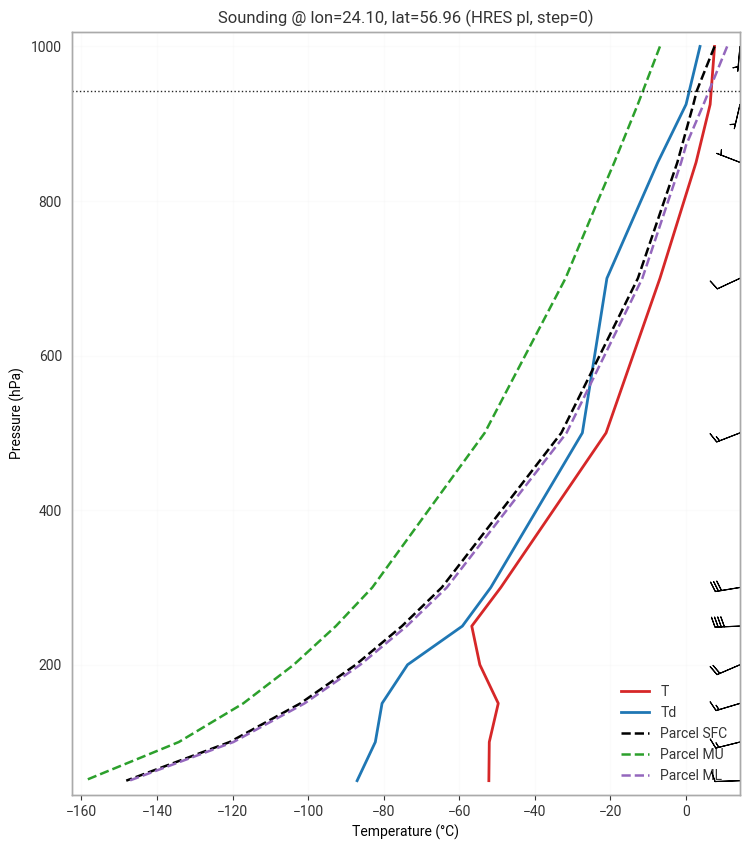

/var/folders/nt/g4thtw252b98vppfh0bk0rnr0000gn/T/ipykernel_11668/3880111712.py:202: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "Shear_0_6km_ms": float(shear_0_6.to('m/s').m),
/var/folders/nt/g4thtw252b98vppfh0bk0rnr0000gn/T/ipykernel_11668/3880111712.py:203: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "Shear_0_6km_kt": float(shear_0_6.to('knots').m),


{'CAPE_SFC_Jkg': 0.0,
 'CIN_SFC_Jkg': 0.0,
 'CAPE_MU_Jkg': 0.0,
 'CIN_MU_Jkg': 0.0,
 'CAPE_ML_Jkg': 0.0,
 'CIN_ML_Jkg': 0.0,
 'LCL_hPa': 942.7705080263243,
 'LCL_m': 603.6119261316753,
 'Shear_0_6km_ms': 16.04299297374776,
 'Shear_0_6km_kt': 31.185083534282906,
 'ThetaE_sfc_K': 294.6237315720076,
 'ThetaE_850_K': 296.5832748605973}

In [9]:
# hres_pl must be the PL file you downloaded (t/u/v + r OR q)
diagnostics = sounding_profile(
    pl_path=hres_pl,
    lon=lon,
    lat=lat,
    title_prefix="Sounding",
    step_index=0,    # change if your PL file has multiple steps
    barb_every=1
)
diagnostics


## 8. Difference maps — utilities & design (used by Section 9 comparisons)

### Why this step
When comparing sources (e.g., **AIFS vs IFS**) or products (e.g., **ENS control vs deterministic**), you need reliable, **artifact-free** differences:
- grids must match,
- longitudes must wrap cleanly,
- units must be compatible,
- colour scales must be symmetric around **0**.

### What these helpers do
- **Load → xarray**: pick a field by `shortName` from a GRIB and return a tidy `DataArray`.
- **Harmonise grids**: wrap longitudes to **[-180, 180)** and, when necessary, **interpolate B → A** to avoid seams.
- **Units**: do minimal, explicit conversions only when needed (e.g., **Pa → hPa**); otherwise strip unit metadata so plotting libraries don’t auto-convert.
- **Colour scale**: center at **0** with robust symmetric limits using the **98th percentile** of |diff| (with a small floor so weak differences remain visible).
- **Maps**: `cartopy` Plate Carree, thin coastlines/gridlines, horizontal colorbar—clean and reproducible.

### Where this is used
The next section calls these helpers to produce three “apples-to-apples” comparisons for the pinned run:
1. **Waves** — SWH: **ENS control − deterministic**  
2. **2 m temperature** — **AIFS − IFS** (°C)  
3. **MSLP** — **AIFS − IFS** (hPa)

### Tips
- If a comparison shows “(missing)”, the preflight likely skipped a file that wasn’t published yet—re-run later or relax your preflight window.
- Small or featureless differences (especially for waves at short lead times) are expected if both systems agree closely.
- You can change the domain from `"global"` to a region for a closer look (e.g., `"Europe"`, `"USA"`).


In [21]:
# --- Section 9 helpers: load→xarray, grid harmonisation, robust difference plotting
from pathlib import Path
import numpy as np
import xarray as xr
import earthkit.data as ekd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.cm import get_cmap

def _pick_field_da(path_like, short):
    """Open GRIB at path and return a DataArray for `short` with dims (latitude, longitude)."""
    if not path_like:
        return None
    p = Path(path_like)
    if not p.exists() or p.stat().st_size == 0:
        return None

    ds = ekd.from_source("file", str(p))
    # Prefer exact shortName match
    fld = None
    try:
        fld = ds.sel(shortName=short)[0]
    except Exception:
        try:
            fld = ds[0]
        except Exception:
            return None

    xa = fld.to_xarray()
    if isinstance(xa, xr.Dataset):
        # take the first data var if needed
        xa = xa[next(iter(xa.data_vars))]
    # normalise coord names and order
    ren = {}
    if "lon" in xa.coords: ren["lon"] = "longitude"
    if "lat" in xa.coords: ren["lat"] = "latitude"
    if ren: xa = xa.rename(ren)
    if "latitude" in xa.dims and "longitude" in xa.dims:
        xa = xa.transpose("latitude", "longitude", *[d for d in xa.dims if d not in ("latitude","longitude")])
    return xa

def _wrap_lon_180(da):
    """Wrap longitudes to [-180,180) to avoid seams, sort both axes."""
    if "longitude" not in da.coords:
        return da
    lon = xr.where(da.longitude > 180, da.longitude - 360, da.longitude)
    da = da.assign_coords(longitude=lon)
    return da.sortby(["latitude", "longitude"])

def _harmonise_grids(A, B):
    """Return (A', B') on the same lat/lon grid by wrapping and interpolating B→A if needed."""
    A = _wrap_lon_180(A)
    B = _wrap_lon_180(B)
    same_lat = np.array_equal(A.latitude.values, B.latitude.values)
    same_lon = np.array_equal(A.longitude.values, B.longitude.values)
    if not (same_lat and same_lon):
        B = B.interp(latitude=A.latitude, longitude=A.longitude)
    return A, B

def _symmetric_limits(arr, pctl=98, floor=1.0):
    """Robust symmetric limits around 0 using |values| percentiles, with a minimum floor."""
    p = np.nanpercentile(np.abs(arr), pctl)
    vmax = float(max(p, floor))
    return (-vmax, vmax)

def _plot_diff_map(diff, units_label, title, domain="global", pctl=98, floor=1.0, cmap_name="RdBu_r"):
    """Cartopy map with robust symmetric colour limits centered at 0."""
    # strip unit metadata so no unit library tries to convert
    diff = diff.copy()
    diff.attrs.pop("units", None)

    vmin, vmax = _symmetric_limits(diff.values, pctl=pctl, floor=floor)
    cmap  = get_cmap(cmap_name)

    try:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    except Exception:
        norm = Normalize(vmin=vmin, vmax=vmax)

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(9.2, 4.8), subplot_kw=dict(projection=proj))
    ax.coastlines(); ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

    im = diff.plot(ax=ax, transform=proj, cmap=cmap, norm=norm, add_colorbar=False)
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.05)
    cb.set_label(units_label)

    ax.set_title(title)
    plt.tight_layout(); plt.show()

    # Quick sanity line
    print(f"NaN %: {np.isnan(diff.values).mean()*100:.2f}  |  min/max: {np.nanmin(diff.values):.3g} / {np.nanmax(diff.values):.3g}")


## 9a. Waves — SWH (ENS control − deterministic)

We compare **significant wave height (SWH)** between the wave **ENS control** and the **deterministic** wave run (both at step 0).  
Because the control member is dynamically very close to deterministic, differences are often **small** and spatially smooth.

- Units: meters (m)
- Expectation: |ΔSWH| is typically small except near energetic systems or resolution/initialisation nuances.
- If the map looks blank: the difference may be near zero — the robust scaling keeps it visible, but values can still be tiny.


/var/folders/nt/g4thtw252b98vppfh0bk0rnr0000gn/T/ipykernel_11668/1124427166.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = get_cmap(cmap_name)


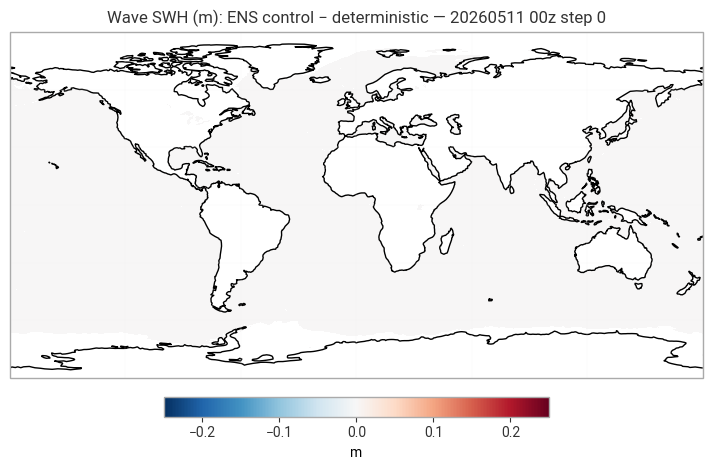

NaN %: 46.13  |  min/max: 0 / 0


In [22]:
# --- 9a) Waves: SWH (ENS control − deterministic) in meters ---
if wave_ens and Path(wave_ens).exists() and wave_det and Path(wave_det).exists():
    A = _pick_field_da(wave_ens, "swh")   # ENS control
    B = _pick_field_da(wave_det, "swh")   # deterministic
    if (A is None) or (B is None):
        print("Wave SWH not found in one of the files; skipping.")
    else:
        A, B = _harmonise_grids(A, B)
        diff_swh = (A - B).assign_attrs(units="m")
        _plot_diff_map(diff_swh, "m",
                       title=f"Wave SWH (m): ENS control − deterministic — {fc_date} {fc_time}z step 0",
                       pctl=98, floor=0.25)
else:
    print("Wave files missing; skipping SWH comparison.")


## 9b. 2 m Temperature — AIFS − IFS

We compare **AIFS** vs **IFS** for the **2 m temperature** at step 0. The subtraction is done after converting to **°C** (difference is identical to K, we just label °C).

- Units: °C
- Expectation: synoptic structure should match; differences are usually small-to-moderate, with regional patterns.
- Caveat: make sure both files are the **same step** and **run time** (the preflight pins the run and step 0).


/var/folders/nt/g4thtw252b98vppfh0bk0rnr0000gn/T/ipykernel_11668/1124427166.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = get_cmap(cmap_name)


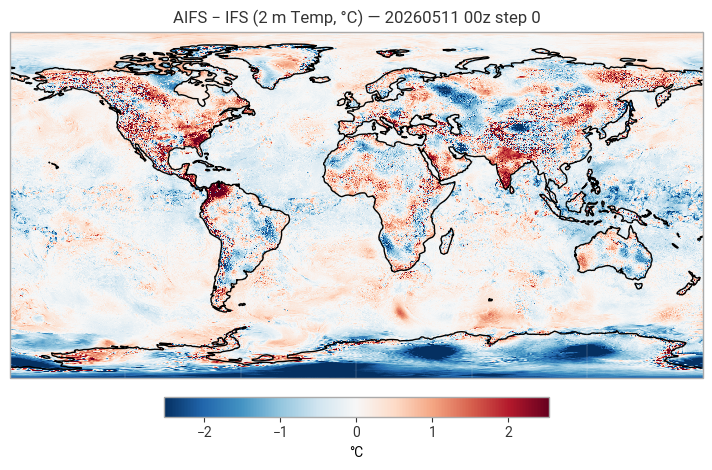

NaN %: 0.00  |  min/max: -8.97 / 11.9


In [23]:
# --- 9b) 2 m Temperature: AIFS − IFS in °C (difference identical in K/°C, we label °C) ---
if aifs_sfc and Path(aifs_sfc).exists() and hres_sfc and Path(hres_sfc).exists():
    A = _pick_field_da(aifs_sfc, "2t")   # Kelvin
    B = _pick_field_da(hres_sfc, "2t")   # Kelvin
    if (A is None) or (B is None):
        print("2t not found in AIFS or IFS file; skipping.")
    else:
        A, B = _harmonise_grids(A, B)
        # convert to °C for user-facing values (difference is the same either way)
        A_c = A - 273.15
        B_c = B - 273.15
        diff_2t = (A_c - B_c).assign_attrs(units="°C")
        _plot_diff_map(diff_2t, "°C",
                       title=f"AIFS − IFS (2 m Temp, °C) — {fc_date} {fc_time}z step 0",
                       pctl=98, floor=1.0)
else:
    print("AIFS or HRES surface file missing; skipping 2 m temperature comparison.")


## 9c. Mean Sea Level Pressure — AIFS − IFS

We compare **MSLP** (AIFS − IFS) at step 0. Fields are distributed in **Pa**, but we display the difference in **hPa**.

- Units: hPa
- Expectation: near-zero mean with coherent synoptic patterns; ±1–4 hPa differences are common at this resolution.
- Visual scaling: symmetric, robust to outliers (98th percentile), centered at 0.


/var/folders/nt/g4thtw252b98vppfh0bk0rnr0000gn/T/ipykernel_11668/1124427166.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = get_cmap(cmap_name)


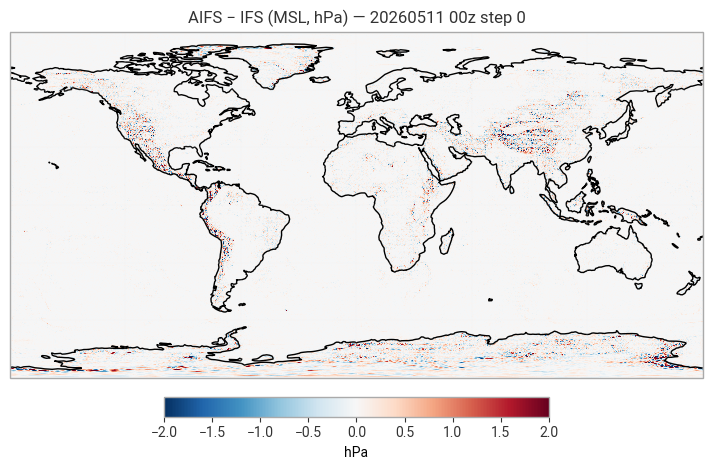

NaN %: 0.00  |  min/max: -5.94 / 5.42


In [24]:
# --- 9c) MSLP: AIFS − IFS in hPa ---
if aifs_sfc and Path(aifs_sfc).exists() and hres_sfc and Path(hres_sfc).exists():
    A = _pick_field_da(aifs_sfc, "msl")  # Pa
    B = _pick_field_da(hres_sfc, "msl")  # Pa
    if (A is None) or (B is None):
        print("msl not found in AIFS or IFS file; skipping.")
    else:
        A, B = _harmonise_grids(A, B)
        A_hpa = A / 100.0
        B_hpa = B / 100.0
        diff_msl = (A_hpa - B_hpa).assign_attrs(units="hPa")
        _plot_diff_map(diff_msl, "hPa",
                       title=f"AIFS − IFS (MSL, hPa) — {fc_date} {fc_time}z step 0",
                       pctl=98, floor=2.0)
else:
    print("AIFS or HRES surface file missing; skipping MSLP comparison.")


## Take-home messages

- The `ecmwf-opendata` client handles safe run selection, retries, and caching
- `earthkit.data.from_source('ecmwf-open-data', ...)` is the idiomatic earthkit approach
- IFS vs AIFS comparison is straightforward — same fields, different source
- Africa wind quiver: set `area=[40, -20, -40, 55]` in your request
- ENS spread plots: select perturbed members with `type='pf'`, control with `type='cf'`

---

### Next steps
- **A03** — Cloud endpoints (AWS S3 HTTP Range for single-parameter slicing)
- **B01** — ERA5 reanalysis via CDS (same earthkit workflow, historical data)
- **B02** — Seasonal forecasts (SEAS5 precipitation outlook over Africa)

### Support
- Questions: [support.ecmwf.int](https://support.ecmwf.int)
- earthkit docs: [earthkit.readthedocs.io](https://earthkit.readthedocs.io)
